# Rotor observer session

The rotor observer on the board's own PMSM model.

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated_device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


Device 10 has two sample sources: the converters, and a motor model the firmware steps in the same interrupt. On the model the law needs no reference and no stage, and the rotor's true angle is known, so the observer can be watched against it.

In [3]:
drive = device.drive
drive.source('model')
print(drive.model_param(j=2e-5, b=1e-5, load=0.0, noise=0.0))
print(drive.model())
print({k: drive.params()[k] for k in ('motor_r_uohm', 'motor_ld_nh', 'motor_lq_nh',
                                       'motor_lambda_uvs', 'motor_pole_pairs')})

{'j': 2e-05, 'b': 1e-05, 'load': 0.0, 'noise': 0.0}
{'source': 'model', 'theta': 0.0, 'omega': 0.0, 'id': 0.0, 'iq': 0.0, 'vdc': 24.773654937744144, 'theta_hat': 0.0, 'omega_hat': 0.0, 'error': 0.0}
{'motor_r_uohm': 0.05, 'motor_ld_nh': 2e-05, 'motor_lq_nh': 2.5e-05, 'motor_lambda_uvs': 0.005, 'motor_pole_pairs': 7.0}


In [4]:
import time

drive.setpoint(id_ref=0.0, iq_ref=0.05, theta=0.0, omega_target=0.0)
drive.mode('sensorless')
rows = []
t0 = time.monotonic()
while time.monotonic() - t0 < 4.0:
    m = drive.model()
    rows.append((time.monotonic() - t0, m['theta'], m['theta_hat'], m['error'],
                 m['omega'], m['omega_hat']))
    time.sleep(0.05)
state = drive.state()
drive.off()
print({k: state[k] for k in ('mode', 'fault', 'omega_hat', 'iq', 'vq', 'periods',
                             'isr_cycles_max', 'exit_ticks_max', 'cycles')})

{'mode': 'sensorless', 'fault': None, 'omega_hat': 1593.179261009371, 'iq': 0.05, 'vq': 7.968396305046856, 'periods': 201672, 'isr_cycles_max': 1620, 'exit_ticks_max': 2921, 'cycles': {'sample': 610, 'step': 1690, 'advance': 620}}


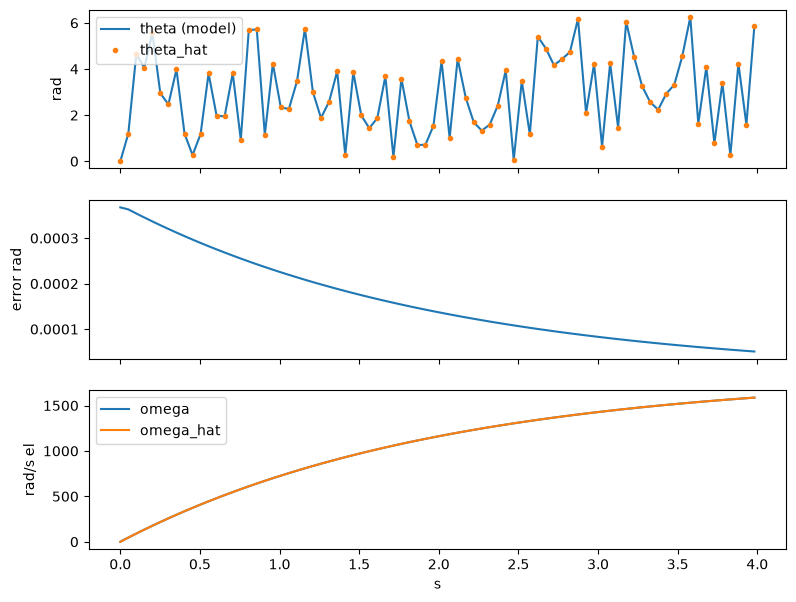

In [5]:
import matplotlib.pyplot as plt

t = [r[0] for r in rows]
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(9, 7))
axes[0].plot(t, [r[1] for r in rows], label='theta (model)')
axes[0].plot(t, [r[2] for r in rows], '.', label='theta_hat')
axes[0].set_ylabel('rad'); axes[0].legend()
axes[1].plot(t, [r[3] for r in rows]); axes[1].set_ylabel('error rad')
axes[2].plot(t, [r[4] for r in rows], label='omega')
axes[2].plot(t, [r[5] for r in rows], label='omega_hat')
axes[2].set_ylabel('rad/s el'); axes[2].set_xlabel('s'); axes[2].legend()
plt.show()

The window since the last take: means and deviations per field, the innovation's autocorrelation for the whiteness test, the peak current.

In [6]:
w = drive.window()
print('n', w['n'], 'i_peak', w['i_peak'])
for name, f in w['fields'].items():
    print('%-4s n %-7s mean %s sd %s' % (name, f['n'], f['mean'], f['sd']))
print('rho', [round(r, 4) for r in w['rho']])
drive.model_reset()
drive.source('adc')
device.close()

n 231204 i_peak 0.06
id   n 231204  mean 0.0 sd 0.02
iq   n 231204  mean 0.0 sd 0.02
vd   n 231204  mean 0.0 sd 0.01
vq   n 231204  mean 0.0 sd 0.01
eps  n 115602  mean 0.0 sd 0.0
ih   n 115602  mean 0.0 sd 0.014142135623730949
vdc  n 231204  mean 24.773654937744144 sd 0.003
rho [0.0032, 0.0004, -0.0057, 0.0073, -0.0076, -0.0068, 0.0005]


## Conclusions

In [7]:
import math

errors = [abs(r[3]) for r in rows]
rms = math.sqrt(sum(e * e for e in errors) / len(errors))
print('rotor            %.1f to %.1f rad/s electrical'
      % (min(r[4] for r in rows), max(r[4] for r in rows)))
print('observer error   %.4f rad rms, worst %.4f rad (%.2f deg)'
      % (rms, max(errors), math.degrees(max(errors))))
print('period           %.1f us, %d cycles a period at %.0f MHz'
      % (state['ts'] * 1e6, state['isr_cycles_max'], 475.0))
print('exit             %d TIM1 ticks past the trigger, of %d in a period'
      % (state['exit_ticks_max'], 2 * 2375))
print('virtual step     sample %d, law %d, advance %d cycles'
      % (state['cycles']['sample'], state['cycles']['step'], state['cycles']['advance']))
print('window           %d periods, i_peak %.3f A' % (w['n'], w['i_peak']))

rotor            0.1 to 1586.8 rad/s electrical
observer error   0.0002 rad rms, worst 0.0004 rad (0.02 deg)
period           20.0 us, 1620 cycles a period at 475 MHz
exit             2921 TIM1 ticks past the trigger, of 4750 in a period
virtual step     sample 610, law 1690, advance 620 cycles
window           231204 periods, i_peak 0.060 A


Device 10 has two sample sources. On the converters the law reads the injected triple; on the model it reads a PMSM the firmware steps in the same interrupt, so it runs with the AFE off, no stage, and a rotor whose true angle is known - the only way the observer's error can be measured at all.

`theta_hat` and the model's `theta` ride one reply: two requests are 15 ms apart, six radians at 440 rad/s, so an error across two round trips would be the link's.

At -O0 with the caches off a step was 10 040 cycles, 21 us against a 20 us period, and the interrupt outgrew it. With the instruction cache on and -O2 it is 6 756, and the board steps at 2 922 cycles a period with the drivers unpowered (FINDINGS, *The caches were off*).

`rho` is the innovation's autocorrelation: a residual that is not white is a model that is wrong, and `ljung_box` judges it.